# for Trace    
  - 滥用Event_unit,需要去除Unit操作
  - Trace中Execute的Subject和Object都为Process，其Subject与Object本质上是同一个进程（系统分配资源），只是subject通过LoadLibrary执行了其他功能，为做区分将不同功能的相同进程视为不同的Process实体，并使用Execute表示二者之间关系
- 不要想着代码适配所有数据集，只要适配自己的需求就可以了
  - Cadets和Trace选取案例不涉及IPC，不考虑所有IPC通信。理论上可以说，但实际上不考虑。
  - 当前数据集在如何将Socket Server和Client对应起来描述一个正常的通信流程也存在问题。
- 先设计一个数据提取方法能够完整地把攻击活动提取出来
  - 在提取地过程中发现问题 --- 解决问题

In [ ]:
# ta1-cadets-e3-official-2.json
# 500,0000 -> 2135494  -> 537442 -> 166497 

# 日志解析：舍弃不关心的事件和实体，从关心的日志中提取需要的内容

In [1]:
ConderingObject=['NetFlowObject','FILE_OBJECT_FILE','FILE_OBJECT_BLOCK','SRCSINK_IPC','FILE_OBJECT_UNIX_SOCKET','UnnamedPipeObject','RegistryKeyObject','FILE_OBJECT_DIR','FILE_OBJECT_LINK']  # 除此之外全部忽略
# SRCSINK_IPC --> CreateObject UnamedPipe --> Write\Read.....
# ACCEPT  UNIX_SOCKET,UNIX_SOCKET/NetFlowObject  

IgnoreEvent=['EVENT_MPROTECT', 'EVENT_TRUNCATE', 'EVENT_CHANGE_PRINCIPAL', 'EVENT_MODIFY_FILE_ATTRIBUTES', 'EVENT_OTHER','EVENT_CLOSE','EVENT_OPEN','EVENT_SIGNAL','EVENT_WRITE_SOCKET_PARAMS',
             'EVENT_LOGIN','EVENT_BOOT','EVENT_READ_SOCKET_PARAMS','EVENT_ADD_OBJECT_ATTRIBUTE','EVENT_MODIFY_PROCESS','EVENT_CHECK_FILE_ATTRIBUTES','EVENT_DUP','EVENT_LSEEK','EVENT_FCNTL','EVENT_EXIT',
             'EVENT_SHM','EVENT_BIND','EVENT_CONNECT','EVENT_ACCEPT','EVENT_RENAME','EVENT_CREATE_OBJECT',] # 忽略事件
            # 经过考虑，连接动作不涉及信息流向，因此忽略

# 日志解析
# 先选取事件较少的攻击活动解析看看效果
# ATLAS日志处理思路：围绕可疑节点进行数据缩减并构建联通图，依据可疑节点从连通图中寻找子图
# 将日志解析为ATLAS的Preprocess格式，而后使用其代码进行处理和观察。
    # 首先确定要保留什么字段
    # 将提取出来的数据保存到txt文件中
import json
# from EntityDict import *

def get_entity_attr(log): # 获取实体所有需要属性
    Entry=json.loads(log)
    Entry_Type=list(Entry['datum'].keys())[0]# 实体类型
    Attr_From=Entry['datum'][Entry_Type]
    try:
        EntityType=Attr_From['type']# 条目类型
    except:
        EntityType=Entry_Type.split('.')[-1]# 条目类型

    Result={}# 返回结果,用字典形式返回结果是不必要的，用列表完全可以。

    if 'Subject' in Entry_Type:  # 提取Subject属性
        Result['Kind']=1

        uuid=Attr_From['uuid']
        Result['Uuid']=uuid

        Result['Type']=EntityType

        # Subject不记录时间戳，因为该实体在子图中的生命周期由其行为体现，只需要给事件标注时间戳即可
        # if Attr_From['startTimestampNanos'] != 0:
        #     RawTimeStamp=Attr_From['startTimestampNanos']
        #     # TimeStamp=timeStampNum(RawTimeStamp)
        # else:
        #     RawTimeStamp=Attr_From['properties']['map']['seen time']
            # TimeStamp=timeStampStr(RawTimeStamp)
        # 需不需要记录父进程？先记录上，不用再说
        try:
            Result['parentSubject']=Attr_From['parentSubject']['com.bbn.tc.schema.avro.cdm18.UUID']
        except:
            Result['parentSubject']=None
        # Result['TimeStamp']=TimeStamp

        try:
            Cmdline=Attr_From['cmdLine']['string']
        except:
            Cmdline=None
        Result['Cmdline']=Cmdline

        try: # 工作目录
            path=Attr_From['properties']['map']['path']
        except:
            path=None
        Result['path']=path

        try: # 工作目录
            name=Attr_From['properties']['map']['name']
        except:
            name=None
        Result['name']=name



    elif 'Event' in Entry_Type:  # 有些实体属性在实体定义中没有记录，需要在事件中补充
        if EntityType not in IgnoreEvent: # 忽略事件
            Result['Kind']=2

            uuid=Attr_From['uuid']
            Result['Uuid']=uuid
            
            
            Result['Type']=EntityType
           

            RawTimeStamp=Attr_From['timestampNanos']
            # TimeStamp=timeStampNum(RawTimeStamp)
            Result['TimeStamp']=RawTimeStamp

            SubjectUUID=Attr_From['subject']['com.bbn.tc.schema.avro.cdm18.UUID']
            Result['SubUUID']=SubjectUUID

           # 只记录ObjectUUID，其余数据在UUID对应的实体中有记录
            
            try:
                ObjUUID1=Attr_From['predicateObject']['com.bbn.tc.schema.avro.cdm18.UUID']
            except:
                return {}
            try:
                Obj1Path=Attr_From['predicateObjectPath']['string']  # Object Path
            except:
                Obj1Path=None
            
            try:
                ObjUUID2=Attr_From['predicateObject2']['com.bbn.tc.schema.avro.cdm18.UUID']
            except:
                ObjUUID2=None
            try:
                Obj2Path=Attr_From['predicateObject2Path']['string'] # Object2 Path
            except:
                Obj2Path=None
            

            if ObjUUID2 == "00000000-0000-0000-0000-000000000000":# Trace
                ObjUUID2=None# 统一处理为None
            Result['ObjUUID1']=ObjUUID1
            Result['ObjUUID2']=ObjUUID2
            
            try:# EXECUTE特殊属性，指明执行内容
                Cmdline=Attr_From['properties']['map']['cmdLine']
            except:
                Cmdline=None
            Result['Cmdline']=Cmdline

            try:# For Mmap，指明操作目的
                arg_mem_flags=Attr_From['properties']['map']['arg_mem_flags']
            except:
                arg_mem_flags=None
            Result['arg_mem_flags']=arg_mem_flags


            Result['Obj1Path']=Obj1Path
            Result['Obj2Path']=Obj2Path
            # print(Result)
    elif 'Object' in Entry_Type:                       # 提取Object属性
        if EntityType in ConderingObject:
            Result['Kind']=3
            
            uuid=Attr_From['uuid']
            Result['Uuid']=uuid

            Result['Type']=EntityType

            try:
                Path=Attr_From['baseObject']['properties']['map']['path']
            except:
                try:
                    Path=Attr_From['baseObject']['properties']['map']['filename']
                except:
                    Path=None
            Result['Path']=Path

            # 处理网络连接对象的特殊属性
            try:  
                LocalAddress=Attr_From['localAddress']
            except:
                LocalAddress=None
            Result['localAddress']=LocalAddress

            try:  
                LocalPort=Attr_From['localPort']
            except:
                LocalPort=None
            Result['LocalPort']=LocalPort

            try:  
                remoteAddress=Attr_From['remoteAddress']
            except:
                remoteAddress=None
            Result['remoteAddress']=remoteAddress

            try:
                RemotePort=Attr_From['remotePort']
            except:
                RemotePort=None
            Result['remotePort']=RemotePort
            

    return Result

In [3]:
# PreProcess For DARPATC
# 以减少冗余数据为目的对日志中的关键数据进行筛选，只保留需要的数据，其余的数据全部删除。
# 只过滤不需要的事件和实体，不做实体的聚合
# 保留Socket和pipe作为进程间通信媒介，减小编程复杂度。
import os
import pickle
from tqdm import tqdm

def PreProcessForDARPATC(InputPath,OutputPath):
    with open(InputPath,'r',encoding='utf-8') as fRead,open(OutputPath,'w',encoding='utf-8') as fWrite,open(OutputPath+'.data','wb') as fData:
        Datas=fRead.readlines()
        BinRes=[]
        for Item in tqdm(Datas,desc='PreProcessForDARPATC:' + InputPath):
            # Item=json.loads(Item)
            Result=get_entity_attr(Item)
            if Result:# 如果结果存在
                Wanted=list(Result.values())
                fWrite.write(str(list(Wanted))+'\n')# 保存txt可读
                BinRes.append(Wanted)
                # 保存bin直接读取不用处理字符串
        pickle.dump(BinRes,fData)
    
Paths=["D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\"]
# Path=
for Path in Paths:
    PathTest=os.listdir(Path +'\\RawData')
    for File in PathTest:

        if 'PreProcess' not in File:
            InTarget=os.path.join(Path,'RawData\\' + File)
            OutTarget=os.path.join(Path,'DataWithFullInfo\\PreProcess_'+File)
            PreProcessForDARPATC(InTarget,OutTarget)
#

PreProcessForDARPATC:D:\DataStorge\IdeaOne\TargetData\DarpaTC\Trace\RawData\ta1-trace-e3-official-1.json.3: 100%|██████████| 5000000/5000000 [00:50<00:00, 99050.42it/s] 


# 数据缩减：冗余事件过滤、重复事件合并

In [8]:
# 在python3.6后，字典是有序的，记录了元素的插入顺序
# 不要在很小的细节上浪费精力。有很多事件完全可以模糊化处理，因为其在数据集中的攻击活动中没有出现或很少出现。
# Subject=['Kind','Uuid','Type','parentSubject','Cmdline','path','name']
# Event=['Kind','Uuid','Type','TimeStamp','SubUUID','ObjUUID1','ObjUUID2','CmdLine','arg_mem_flags','Obj1Path','Obj2Path']
# Object=['Kind','Uuid','Type','Path','localAddress','LocalPort','remoteAddress','remotePort']

SubjectMerged={'SUBJECT_PROCESS':'PROCESS','SUBJECT_UNIT':'PROCESS'} # 用不到
ObjectMerged={'FILE_OBJECT_FILE':'File','FILE_OBJECT_DIR':'File','FILE_OBJECT_LINK':'File','FILE_OBJECT_BLOCK':'File','RegistryKeyObject':'File',
             'SRCSINK_IPC':'IPC_MEDIUM','UnnamedPipeObject':'IPC_MEDIUM','FILE_OBJECT_UNIX_SOCKET':'SOCKET',
              'NetFlowObject':'NetworkConnection'}  # NetFLOWOBJECT需要缩减
# UNIX_SOCKET相当于进程对外的“联系站”，进程的所有网络连接都通过UNIX_SOCKET建立，因此UNIX_SOCKET可以看作是进程与网络连接的桥梁
# UNIX_SOCKET一定是成对出现的，有Server就有client，在DARPATC中如何将其对应起来？

EventMerged={'EVENT_WRITE':'SENDINFO','EVENT_SENDMSG':'SENDINFO','EVENT_FLOWS_TO':'SENDINFO','EVENT_SENDTO':'SENDINFO',
             'EVENT_READ':'GETINFO','EVENT_RECVMSG':'GETINFO','EVENT_RECVFROM':'GETINFO',
             'EVENT_UNIT':'CREATEPROC','EVENT_CLONE':'CREATEPROC','EVENT_FORK':'CREATEPROC',  # 将UNIT操作视为CreateProcess会导致Connection的连接动作与使用动作出现在两个不同的实体中，但这两个实体之间有严格的控制关系。
             'EVENT_MMAP':'SENDGETINFO',# 只考虑将文件映射进内存的情况，在事件中会注明MMAP的目的，可以用该属性判断数据流或控制流。
             'EVENT_EXECUTE':'EXECUTE','EVENT_LOADLIBRARY':'LOADLIBRARY',# cadets与Trace在execute的描述上有差异，但最终目的一致，需要分情况处理。 目的数据集中不存在LOADLIBRARY事件，暂不做处理。
            #  'EVENT_CREATE_OBJECT':'CREATEFILE',# 不考虑CreateObject，因为其不涉及信息流
             'EVENT_UNLINK':'DELETE',    # 该操作虽然与信息流无关，但涉及攻击行为较为明显，故保留
            #  'EVENT_CONNECT':'CONNECT','EVENT_ACCEPT':'ACCEPT',
             'LOADLIBRARY':'LOADLIBRARY',
             'EVENT_UPDATE':'OTHERS'} # 人造标签

In [9]:
# 将预处理的数据构造成图，在构图的过程中完成事件的聚合（只保留路径上的因果关系）和事件类型的归并
# 直接读取data文件
# Subject=['Kind','Uuid','Type','parentSubject','Cmdline','path','name']
# Event=['Kind','Uuid','Type','TimeStamp','SubUUID','ObjUUID1','ObjUUID2','CmdLine','arg_mem_flags','Obj1Path','Obj2Path']
# Object=['Kind','Uuid','Type','Path','localAddress','LocalPort','remoteAddress','remotePort']
import networkx as nx
import pickle
from tqdm import tqdm
def RawDataToGraph(InputPath):# 输入为.data数据，输出为事件类型归并后的路径级因果图G。
    G=nx.MultiDiGraph()
    with open(InputPath,'rb') as fData:
        RawData=pickle.load(fData)
        Sequence=1
        NetWorkConnection={} # 记录存在的网络连接对  key:ip-port  value:Firstuuid
        NetConnectionMapping={} # 记录相同网络连接对的IP地址 key:ReducedUUid,value:Firstuuid
        
        UnitMapping={} # 记录存在的Unit对 key:parentSubject-uuid  value:Firstuuid
        UpdateMapping = {} # 记录Update对文件的更新

        GetInfoRecoder=[]
        SendInfoRecoder=[]
        MMAPRecoder=[]
        UNLINKrecoder=[]

        for Item in tqdm(RawData,desc=InputPath):# 区分条目属性

             # 合并源目的相同的网络连接          
            if Item[5] in NetConnectionMapping:
                Item[5]=NetConnectionMapping[Item[5]]
            if Item[6] in NetConnectionMapping:
                Item[6]=NetConnectionMapping[Item[6]]

            if Item[0]==1:#Subject 不需要去重
                if Item[1] not in UnitMapping:
                    G.add_node(Item[1],type='SUBJECT_PROCESS',parentSubject=Item[3],Cmdline=Item[4],path=Item[5],name=Item[6]) # 只要属于Subject类默认为Process
            if Item[0]==2:#Event
                
                # 去掉Unit事件影响
                if Item[4] in UnitMapping:
                    Item[4]=UnitMapping[Item[4]]
                if Item[5] in UnitMapping:
                    Item[5]=UnitMapping[Item[5]]
                if Item[6] in UnitMapping:
                    Item[6]=UnitMapping[Item[6]]
                # Update事件的文件映射
                if Item[5] in UpdateMapping:
                    Item[5]=UpdateMapping[Item[5]]
                if Item[6] in UpdateMapping:
                    Item[6]=UpdateMapping[Item[6]]

                if Item[2] == 'EVENT_MMAP': # 只考虑读取文件 数据流File2Process
                    # if 'cadets' in InputPath: # cadets的MMAP中，Object只包含一个映射进内存的文件对象
                    #     if Item[5]:
                    #         if (Item[5],Item[4]) not in MMAPRecoder: # 去除重复事件
                    #             G.add_edge(Item[5],Item[4],type=Item[2],Sequence=Sequence,OpAttr=Item[8])# 记录操作属性
                    #             if 'path' not in G.nodes[Item[5]] or G.nodes[Item[5]]['path'] == None:# 有些文件路径在事件中有记录
                    #                 # G.nodes[Item[5]]['path']=Item[9]
                    #                 G.add_node(Item[5],path=Item[9]) 
                    #             MMAPRecoder.append((Item[5],Item[4]))
                    #             Sequence += 1
                    # else:
                    if Item[6]:# Trace中真正将文件映射进内存的事件需要内存对象和文件对象同时出现
                        if (Item[5],Item[4]) not in MMAPRecoder: # 去除重复事件
                            G.add_edge(Item[5],Item[4],type=Item[2],Sequence=Sequence,OpAttr=Item[8])# 记录操作属性
                            if 'path' not in G.nodes[Item[5]] or G.nodes[Item[5]]['path'] == None:# 有些文件路径在事件中有记录，若实体定义时该部分信息没有补充完整，则在此补充
                                # G.nodes[Item[6]]['path']=Item[10]
                                G.add_node(Item[5],path=Item[9]) 
                            MMAPRecoder.append((Item[5],Item[4]))
                            Sequence += 1
                elif Item[2] == 'EVENT_LINK': # RENAME只改变文件的名称,UUID存在且该事件只在Cadets中出现，不考虑。Link，Unlink在删除文件前不体现在事件中。
                    if Item[5] not in G.nodes:
                        G.add_node(Item[5]) # 若文件节点不存在，则创建
                    if 'link' in  G.nodes[Item[5]]:
                        G.nodes[Item[5]]['link']+=1
                    else:
                        G.nodes[Item[5]]['link']=1
                elif Item[2] == 'EVENT_UNLINK': # RENAME只改变文件的名称,UUID存在且该事件只在Cadets中出现，不考虑。Link，Unlink在删除文件前不体现在事件中。
                    if Item[5] not in G.nodes:
                        G.add_node(Item[5]) # 若文件节点不存在，则创建
                    if 'link' not in  G.nodes[Item[5]] or G.nodes[Item[5]]['link'] == 1:
                        if (Item[4],Item[5]) not in UNLINKrecoder:# 删除文件操作也要去重
                            G.add_edge(Item[4],Item[5],type=Item[2],Sequence=Sequence)# 记录操作属性
                            UNLINKrecoder.append((Item[4],Item[5]))
                            Sequence += 1
                    else:
                        G.nodes[Item[5]]['link']-=1
                elif Item[2] == 'EVENT_EXECUTE': # 数据流 File2Process
                    # if Item[6]:
                        # G.add_edge(Item[6],Item[4],type='LOADLIBRARY',Sequence=Sequence)
                        # if 'path' not in G.nodes[Item[6]] or G.nodes[Item[6]]['path'] == None:# 有些文件路径在事件中有记录，若实体定义时该部分信息没有补充完整，则在此补充
                            # G.nodes[Item[6]]['path']=Item[10]
                            # G.add_node(Item[6],path=Item[10]) 
                    G.add_edge(Item[4],Item[5],type=Item[2],Sequence=Sequence,Cmdline=Item[7])# Trace的EVENT_EXECUTE与Cadets、Trace不同
                    if 'path' not in G.nodes[Item[5]] or G.nodes[Item[5]]['path'] == None:
                            # G.nodes[Item[5]]['path']=Item[9]
                            G.add_node(Item[5],path=Item[9]) 
                    Sequence += 1
                # elif Item[2] == 'EVENT_CREATE_OBJECT': # 控制流Process2File
                #     if Item[6]==None:# 不考虑SocketPair
                #         G.add_edge(Item[4],Item[5],type=Item[2],Sequence=Sequence)
                #         Sequence+=1
                elif EventMerged[Item[2]] == 'SENDINFO': # 数据流 Process2File
                    #  if Item[5] in NetConnectionMapping: # 合并源目的相同的网络连接
                        #  Item[5]=NetConnectionMapping[Item[5]]
                     if (Item[4],Item[5]) not in SendInfoRecoder: # 去除重复事件
                        G.add_edge(Item[4],Item[5],type=Item[2],Sequence=Sequence)
                        if 'path' not in G.nodes[Item[5]] or G.nodes[Item[5]]['path'] == None:
                            # G.nodes[Item[5]]['path']=Item[9]
                            G.add_node(Item[5],path=Item[9]) 
                        SendInfoRecoder.append((Item[4],Item[5]))
                        Sequence += 1
                elif EventMerged[Item[2]] == 'GETINFO': # 数据流 File2Process
                    if (Item[5],Item[4]) not in GetInfoRecoder: # 去除重复事件
                        G.add_edge(Item[5],Item[4],type=Item[2],Sequence=Sequence)
                        if 'path' not in G.nodes[Item[5]] or G.nodes[Item[5]]['path'] == None:
                            # G.nodes[Item[5]]['path']=Item[9]
                            G.add_node(Item[5],path=Item[9]) 
                        GetInfoRecoder.append((Item[5],Item[4]))
                        Sequence += 1       
                elif Item[2] == 'EVENT_LOADLIBRARY': # 该事件信息流向是文件 -》 进程
                    G.add_edge(Item[5],Item[4],type=Item[2],Sequence=Sequence)
                    if 'path' not in G.nodes[Item[5]] or G.nodes[Item[5]]['path'] == None:
                            # G.nodes[Item[5]]['path']=Item[9]
                            G.add_node(Item[5],path=Item[9]) 
                    Sequence += 1

                elif Item[2] == 'EVENT_UNIT': # 去除该类型边
                    if Item[5] not in UnitMapping:
                        UnitMapping[Item[5]]=Item[4]
                elif Item[2] == "EVENT_UPDATE":
                    if Item[6] not in UpdateMapping:
                        UpdateMapping[Item[6]]=Item[5]
                    
                else:# 其余事件 控制流Process2File，Process2Process
                    G.add_edge(Item[4],Item[5],type=Item[2],Sequence=Sequence)
                    Sequence += 1

            if Item[0]==3:#Object
                if Item[2]=='NetFlowObject':
                    if (Item[4],Item[6]) not in NetWorkConnection: #第一次出现
                        NetWorkConnection[(Item[4],Item[6])] = Item[1]
                        NetConnectionMapping[Item[1]]=Item[1]
                        G.add_node(Item[1],type=Item[2],path=Item[3],localAddress=Item[4],remoteAddress=Item[6]) # 记录主机级的网络连接，不考虑端口，该举动会合并大量网络连接行为。  此种情况下只会记录第一次建立网络连接时的动作，后续动作如果与此次动作重合则不会被记录。此方法有信息丢失的风险，但在当前数据集中是适用的。
                    else:
                        MappingUuid=NetWorkConnection[(Item[4],Item[6])] # MappingUuid是最初的网络连接id，也是被合并的节点
                        # NetWorkConnection[(Item[4],Item[5],Item[6],Item[7])].append(Item[1])
                        NetConnectionMapping[Item[1]]=MappingUuid
                else:
                    G.add_node(Item[1],type=Item[2],path=Item[3],localAddress=Item[4],remoteAddress=Item[6])   
                        
    return G


In [10]:
# 将预处理后的日志解析为溯源图
G=RawDataToGraph("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\DataWithFullInfo\\PreProcess_ta1-trace-e3-official-1.json.3.data")
# G2=RawDataToGraph("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Cadets\\DataWithFullInfo\\PreProcess_ta1-cadets-e3-official-1.json.4.data")
# G2=RawDataToGraph("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\DataWithFullInfo\\PreProcess_ta1-Trace-e3-official-6r.json.8.data")
# G3=RawDataToGraph("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\DataWithFullInfo\\PreProcess_ta1-Trace-e3-official-6r.json.data")



D:\DataStorge\IdeaOne\TargetData\DarpaTC\Trace\DataWithFullInfo\PreProcess_ta1-trace-e3-official-1.json.3.data: 100%|██████████| 2678601/2678601 [7:41:37<00:00, 96.71it/s]   


In [11]:
# 补充节点信息
# import json

ObjectDict={}  # 解析untility.json，获取节点信息
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Untility.json",'r',encoding='utf-8') as f:
    Data=f.readlines()
    for rawLog in tqdm(Data,desc="Prasering Object"):
        Result=get_entity_attr(rawLog) # 只记录了我们关心的实体类型。故没有UnKonwSrc
        # print(Result)
        if Result:
            Wanted = list(Result.values())
            ObjectDict[Wanted[1]]=Wanted


Prasering Object: 100%|██████████| 6428292/6428292 [00:56<00:00, 113144.58it/s]


In [12]:
NodeForRemove = []
for node in G.nodes:
    if 'type' not in G.nodes[node]:
        try:
            Item=ObjectDict[node]
            if Item[0] == 1: # 进程的属性与非进程不同
                G.add_node(Item[1],type='SUBJECT_PROCESS',parentSubject=Item[3],Cmdline=Item[4],path=Item[5]) # 只要属于Subject类默认为Process
            elif Item[0] == 3:  # 文件
                if 'path' not in G.nodes[node] or G.nodes[node]['path'] == None:
                    G.add_node(Item[1],type=Item[2],path=Item[3],localAddress=Item[4],remoteAddress=Item[6]) 
                else:
                    G.add_node(Item[1],type=Item[2],localAddress=Item[4],remoteAddress=Item[6])
        except:
            NodeForRemove.append(node) # 移除所有UnknowSrc
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\RemovedNodes.txt",'w',encoding='utf-8') as f:
    for node in NodeForRemove:
        f.write(node+'\n')

In [13]:
G.remove_nodes_from(NodeForRemove)

In [14]:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_Graph.dot",'w',encoding='utf-8') as f:
    for node in tqdm(G.nodes(data=True)):
        f.write(str(node)+'\n')
    for edge in tqdm(G.edges(data=True)):
        f.write(str(edge)+'\n')

with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_Graph.data",'wb') as f:
    pickle.dump(G,f)

100%|██████████| 61319/61319 [00:00<00:00, 251295.39it/s]


In [15]:
import pickle
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_Graph.data",'rb') as f:
    G=pickle.load(f)

In [ ]:
EdgeTj={}
for edge in G.edges(data=True):
    if edge[2]['type'] not in EdgeTj:
        EdgeTj[edge[2]['type']]=1
    else:
        EdgeTj[edge[2]['type']]+=1
EdgeTj

# 数据缩减：提取节点可达子图

In [ ]:
# 补丁
ConvertEdge = []
for edge in G.edges(data=True):
    if edge[2]['type'] == 'EVENT_LOADLIBRARY':
        # print(edge)
        ConvertEdge.append(edge)
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\\\C315_ConvertEdge.txt",'w',encoding='utf-8') as f:
    for edge in ConvertEdge:
        f.write(str(edge)+'\n')
for edge in ConvertEdge:
    G.remove_edge(edge[0],edge[1])
    G.add_edge(edge[1],edge[0],type='EVENT_LOADLIBRARY',Sequence=edge[2]['Sequence'])

In [ ]:
# 提取与目标节点在信息流或控制流视角下满足单向联通条件的节点子图：确保子图节点之间最起码是单向可达的
	# 除此之外考虑记录进程Read操作（后续会化简）以还原完整攻击活动       
	# 如何构造算法消除可疑节点构造的差异，使得在同一子图中的可疑节点还原出来的子图是一致的？
		# 只有出边，没有入边的非进程节点 以及 只有入边,没有出边的节点（叶子节点）  为边界节点
			# 只有Process有传播控制流的权利，只有出边的Process不能视为边界节点，要做的是将其出边引出的系统活动算作子图的一部分。
		# 要考虑之前数据缩减工作和节点类型带来的边界节点：NetFlowObject就是一类边界节点
		# 子图是由边界节点划分开的，非边界节点会引入邻居进一步扩展子图规模
	# 节点扩展算法如何构建？
		# 异常节点为非Process：寻找其Process邻居节点，从Process开始构建
		# 异常节点为进程：
# 边缘节点判断 
	# 这种判断方法能够保证只提取我们关心的文件传播路径，并能够还原完整的进程活动行为。
def  EdgeNodes(G,TargetNode):
	result = 0
	if len(list( G.predecessors(TargetNode))) == 0 and G.nodes[TargetNode]['type'] != 'Process':# 非进程的无入边节点为边界节点  流起点
		# print(1)
		result = 1
	elif len(list( G.successors(TargetNode))) == 0 :# 无出边节点为边界节点  流终点
		# print(2)
		result = 1
	elif G.nodes[TargetNode]['type'] == 'NetFlowObject':# NetFlowObject为边界节点
		# print(3)
		result = 1
	return result



def construct_G_subgraph(G,Nodelist): # 默认Nodelist相互连通
	# global sub_nodes, node_set, G_subgraph, G
	ResultNodes=set() # 结果节点
	CandidateNode=set(Nodelist) # 候选节点
	while True:
		NetGenCanNode=set()

		for node in CandidateNode:	
			ResultNodes.add(node)
			if EdgeNodes(G,node)==0:# 非边缘节点,将其邻居加入遍历序列   若节点为边缘节点，则只将该节点加入点集，不考虑其前驱或后继
				# print(node)
				successors = G.successors(node) # or neighbors
				predecessors = G.predecessors(node)
				NetGenCanNode=NetGenCanNode.union(successors)
				NetGenCanNode=NetGenCanNode.union(predecessors)
		CandidateNode=NetGenCanNode - ResultNodes # 取差集，否则无限循环
		print(len(CandidateNode))
		if len(CandidateNode)==0:
			break
	G_subgraph = G.subgraph(ResultNodes).copy()# 子图包含指定的节点及其之间的边，不涉及其他节点
	return  G_subgraph
			

	



In [18]:
AnchorNodes=["93E0C854-95A4-FE1B-245B-6E217A409764"]
# a=sorted(G.edges(data=True),key=lambda x:x[2]['Sequence']len()))
SubGraph=construct_G_subgraph(G,AnchorNodes)
# final,Nodelist = get_active_actions_statements(SubGraph)

3
13
31
266
897
1940
2733
6222
159
677
97
122
32
17
3
0


In [19]:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_SubGraph.dot",'w',encoding='utf-8') as f:
    for node in tqdm(SubGraph.nodes(data=True)):
        f.write(str(node)+'\n')
    for edge in tqdm(SubGraph.edges(data=True)):
        f.write(str(edge)+'\n')

100%|██████████| 53562/53562 [00:00<00:00, 337892.06it/s]


In [ ]:
# EdgeNodes(G,"D57B2A07-B373-B75A-B3B3-93790AB76535")
# 移除所有无用通信中介
RemovedNodes=[]
for node in SubGraph.nodes:
    if SubGraph.nodes[node]['type'] == 'FILE_OBJECT_UNIX_SOCKET' or SubGraph.nodes[node]['type'] == 'UnnamedPipeObject':
        if len(list(SubGraph.predecessors(node))) <= 0 or len(list(SubGraph.successors(node))) == 0:  # 中断的信息流动
            RemovedNodes.append(node)
        if list(SubGraph.predecessors(node)) == list(SubGraph.successors(node)):  # 无信息流动,在移除Create_Object事件后再实施
            RemovedNodes.append(node)
SubGraph.remove_nodes_from(RemovedNodes)


In [ ]:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_SubGraph_sk.dot",'w',encoding='utf-8') as f:
    for node in tqdm(SubGraph.nodes(data=True)):
        f.write(str(node)+'\n')
    for edge in tqdm(SubGraph.edges(data=True)):
        f.write(str(edge)+'\n')

# 数据缩减：移除无用信息中间节点，移除公共信息源与目的节点

In [20]:
# 细微错误的矫正 ：1. 日志记录错误 Execute Scoket  2. 重复UnLink操作
RemovedSequence=[]
RemovedNodes=[]
RemovedEdges=[]
for node in SubGraph.nodes:
    if SubGraph.nodes[node]['type'] == 'FILE_OBJECT_UNIX_SOCKET' or SubGraph.nodes[node]['type'] == 'UnnamedPipeObject':
        for edge in SubGraph.edges(node,data=True):
            # print(edge)
            if edge[2]['type'] == 'EVENT_EXECUTE': # 涉及EXECUTE的通信中介全部删除，疑似日志错误
                RemovedNodes.append(node)
                RemovedSequence.append(edge[2]['Sequence'])
SubGraph.remove_nodes_from(RemovedNodes)
for edge in SubGraph.edges(data=True):
    if edge[2]['Sequence'] in RemovedSequence:
        print(edge)
        RemovedEdges.append(edge)
for edge in RemovedEdges:
    SubGraph.remove_edge(edge[0],edge[1])
# SubGraph.remove_edge_from(RemovedEdges)

            # if SubGraph[edge[0]][edge[1]]['type'] == 'EVENT_EXECUTE':
            #     print(edge)

In [ ]:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_SubGraph_sk_db.dot",'w',encoding='utf-8') as f:
    for node in tqdm(SubGraph.nodes(data=True)):
        f.write(str(node)+'\n')
    EdgeSeq=list(SubGraph.edges(data=True))
    EdgeSeq.sort(key=lambda x:x[2]['Sequence'])
    for edge in tqdm(EdgeSeq):
        f.write(str(edge)+'\n')

In [21]:
# 信息源节点 先去掉只与Read\MMAP\LoadLibrary相关的基础信息节点
DeleteType=['EVENT_READ','EVENT_MMAP','EVENT_LOADLIBRARY']
FileType = ['FILE_OBJECT_BLOCK','FILE_OBJECT_FILE','FILE_OBJECT_DIR']
NodeForRemoved=[]
Indector = 10 # 超过此数值为基础信息节点
for node in tqdm(SubGraph.nodes):
    if len(list(SubGraph.predecessors(node))) == 0 and SubGraph.nodes[node]['type'] in FileType: # 只有出边的文件实体
        # print(node)
        if len(list(SubGraph.successors(node))) >= Indector: # 出边数量大于Indector才纳入考虑范围
            NodeForRemoved.append(node)
            for edge in SubGraph.out_edges(node,data=True):
                if edge[2]['type'] not in DeleteType:
                    print(edge[2]['type'])
                    NodeForRemoved.remove(node)
                    break   
print(NodeForRemoved)
SubGraph.remove_nodes_from(NodeForRemoved)



100%|██████████| 13213/13213 [00:00<00:00, 310777.17it/s]

['EB8D3639-5123-6043-BA82-40207D951A10', '261E1102-225E-C0CD-53B9-700AD60DBF6E', '72C841A1-7B33-ECCB-04C5-39537D273E26', '9BC8D388-FB55-58DA-BCB7-CED0CFB25710', 'E11ED7E3-9189-246D-C741-4D8DAF18F306', '255E11AE-1A94-78F3-A10F-F25A16F0D2AE', '9A9CB4C0-2555-B66F-65E1-B60130AE5702', 'A95BB595-3EBA-91A9-C342-A36EC8444351', '4BB45192-9F1B-0603-4E15-D1DA7F5B2A59', 'E47CBA26-EE75-5D1D-E050-7EC8BA13E0E0', 'B95346C2-6ED8-1761-CFD8-8C92E57E304A', '2F894C00-0F3D-8F2E-3DAC-C8F7907B1D02', '33FFECD4-4E03-F575-C76B-F569D2F22479', '725EAC28-A0E9-40DD-FC01-B4EF3F2D5EB6', 'E5ECE37A-8EE4-E02C-C743-4724FA929550', '13D50AC3-D59C-0AB4-1590-864CAB9E512A', 'B14B1018-8712-EF9F-D471-A473B0577D1E', '632C4D0E-495A-1731-089A-7B0F6EEA860D', '2D31BC89-145F-409D-2C49-DF8C3DD5F7EA', '299BBCC9-849E-1C54-FCAD-C29ACB13BF37', '6CB46927-EA62-2FBD-6B20-D3AA9D5A6755', '1CE27C7C-0E24-B23E-4418-64DAB5439AB1', 'FA84C095-A05A-23AA-F572-69ECA85FBF13', 'C57F1343-564E-576D-47F1-5945706DF400', 'A00282CD-03C1-F565-4EFA-2B24640C43D1',

In [22]:
# 公共信息流向删除

DeleteType=['EVENT_WRITE']
NodeForRemoved=[]
Indector = 10 # 超过此数值为基础信息节点
for node in tqdm(SubGraph.nodes):
    if len(list(SubGraph.successors(node))) == 0 and SubGraph.nodes[node]['type'] in FileType: # 只有入边的文件实体
        # print(node)
        if len(list(SubGraph.predecessors(node))) >= Indector: # 出边数量大于Indector才纳入考虑范围
            NodeForRemoved.append(node)
            for edge in SubGraph.in_edges(node,data=True):
                if edge[2]['type'] not in DeleteType:
                    print(edge[2]['type'])
                    NodeForRemoved.remove(node)
                    break   
print(NodeForRemoved)
SubGraph.remove_nodes_from(NodeForRemoved)

100%|██████████| 12249/12249 [00:00<00:00, 532532.05it/s]

[]


In [ ]:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_SubGraph_sk_db_bid.dot",'w',encoding='utf-8') as f:
    for node in tqdm(SubGraph.nodes(data=True)):
        f.write(str(node)+'\n')
    EdgeSeq=list(SubGraph.edges(data=True))
    EdgeSeq.sort(key=lambda x:x[2]['Sequence'])
    for edge in tqdm(EdgeSeq):
        f.write(str(edge)+'\n')

In [23]:
# '终端'概念再Linux中是以文件形式体现的:/dev/tty，代表计算机的输入的输出。
# 参考：<https://cloud.tencent.com/developer/article/1527544>,<https://www.bilibili.com/video/BV1FV411Z7y5/?spm_id_from=333.337.search-card.all.click&vd_source=bfd15b38f2dcd971633f7ff9e3f10ea1>
# 在同一个Bash下，我们在终端进行的输入和输出是不相互影响的,即独立指令之间不会因为终端存在信息的流动。对此需要对该文件作特殊处理。
# Bash:<https://zhuanlan.zhihu.com/p/328045475>
FileType = ['FILE_OBJECT_BLOCK','FILE_OBJECT_FILE','FILE_OBJECT_DIR']
NoNeedNode=[]
MatchChar= ['/dev/tty','/dev/console','/dev/null','/run/shm','/home/admin/.mozilla/firefox']
for node in SubGraph:
    if SubGraph.nodes[node]['type'] in FileType and SubGraph.nodes[node]['path']:
        for MChar in MatchChar:
            if MChar in SubGraph.nodes[node]['path']:
                NoNeedNode.append(node)
                break
print(NoNeedNode)

SubGraph.remove_nodes_from(NoNeedNode) # tty不参与网络活动，只会作为内部节点出现。我们认为每次对tty的读写是独立的操作，不会因为不同进程对tty文件的读写而导致信息的交互。
# SubGraph.remove_nodes_from(NoNeedNode) # SubGraph中也移除此类不关心节点

['EBF2E8E8-4CE5-80EB-8D82-80B9B4126388', 'C17ACBBE-FA63-E04F-9B23-24EC817C4D5D', '2B554E50-503E-48D8-D8AA-47F8C4363AC0', 'C04BE65B-A802-EE2D-A4F7-90C8BA430A31', '472C1C45-5DD8-4A26-8320-F1C677F06726', '0E2E91C8-317B-0556-C4CB-8076755F1351', '30C7AF8B-4B60-6791-59A0-F2DBA27DFA91', 'F6B5A572-5074-9CF8-2EF6-455DF19D0B9D', '2963459B-600E-8867-824A-A457E669577C', '2ED57681-8443-0713-9305-9011ABC9E819', 'D31EA138-89C6-F272-7572-C30467C36246', '415C7268-2774-CAC8-BFA9-ECA7DDFC726F', '4CAF1D95-84CA-90A1-AE20-1501DED10AC8', 'AFDBFEF9-AB4D-B32A-6412-0D02893A3810', 'DD4A09BF-5D5D-E1BF-DB6A-E9E2CE13552B', '34F1EA5C-AD94-5265-02D7-BC521014267E', '571767B7-9A71-BF3B-F9C9-7825A6D08CA3', 'DF541F04-8BCB-C665-76E9-EB56EBEC1E76', '6512CB1D-2567-11A7-93E0-D2185699B270', '9BAF8136-C488-00B6-5FE5-D6F7821A7699', '6E17C2ED-836D-EB14-F391-84790227FFD7', '2FD4CEE0-408B-077C-A664-84D4171F1F11', '7D350AEF-A9ED-ECD5-9160-0BBD2CA7184B', '692465D7-5048-1A1F-8C7E-EB6D92707D7C', '395AA04A-8501-737C-A79A-6B5914DC6F9F',

# 数据缩减：叶子节点合并（read\Write）

In [24]:
# 叶子节点合并  即 合并【单个进程针对多个同类型孤立节点的重复操作】  
# 文件path合并，事件Sequence取最初的一个：将所有文件path合并到最初的UUID上，使用其代替所有文件
# 信息终点

Merged={} # key:(Process,EventType)  value:[node1,node2,.....]

CandidateNode=[]

RemovedNodes=[]
for node in SubGraph.nodes:
    if len(list(SubGraph.successors(node))) == 0 and len(list(SubGraph.predecessors(node))) == 1 and SubGraph.nodes[node]['type'] in FileType:  # 找到所有同类型孤立节点:类型为文件、无出边，只有一条入边
        CandidateNode.append(node)
for node in CandidateNode:
    # print(node)
    # print(list(SubGraph.in_edges(node,data=True)))
    Edge=list(SubGraph.in_edges(node,data=True))[0] #获取边信息
    if (Edge[0],Edge[2]['type']) not in Merged:
        Merged[(Edge[0],Edge[2]['type'])] = [node]
    else:
        Merged[(Edge[0],Edge[2]['type'])].append(node)
print(Merged)
for Item in tqdm(Merged):
    if len(Merged[Item]) > 1:
        MergedPath=''
        MergedSequence=9999999
        for node in Merged[Item]:
            Edge=list(SubGraph.in_edges(node,data=True))[0]
            if Edge[2]['Sequence']<MergedSequence: # 事件序列
                MergedSequence=Edge[2]['Sequence']
            if SubGraph.nodes[node]['path'] != None:  # 节点属性
                MergedPath += ';' + SubGraph.nodes[node]['path']
        RemovedNodes=Merged[Item][1:] # 选取第一个节点为合并节点
        SubGraph.nodes[Merged[Item][0]]['path'] = MergedPath # 修改节点属性

        OldEdge=list(SubGraph.in_edges(Merged[Item][0],data=True))[0] # 获取旧边
        SubGraph.remove_edge(OldEdge[0],OldEdge[1])# 删除旧边

        SubGraph.add_edge(Item[0],Merged[Item][0],type=Item[1],Sequence=MergedSequence) # 添加新边
        SubGraph.remove_nodes_from(RemovedNodes) # 移除其余节点
        print(RemovedNodes)



        



{('5D307708-B178-5F4B-0FAE-AA64552870FD', 'EVENT_UNLINK'): ['95E044C3-CD77-6E49-618A-E1315C05AB8E', '40D40407-FE6C-B4F4-A0DD-C47D7158A2A8', 'BDECCD6B-472B-4A50-5801-E7E424DB1687', '6EC96BFB-6FBD-80E5-9CC3-A508A8E4EAD6', '0CBF24AA-1D07-F4F5-C08F-B28AFDA38BDC', 'EB43BF3E-F8FD-EAEF-B0EB-5E38AEE78DC7', '07926658-F0E7-2CF3-28DA-84780E71EE0F', '2232A6C1-D112-43E5-820A-6DF590C1C2DE', '4C86A561-5662-66E3-2871-1795EC9ADA48', 'C52280B3-D8C9-4E2B-17A4-2FBFC6E525C1', 'A5DCC126-CDD0-4C1B-6ACE-6E03492A5E27', 'E2211F06-BB33-1463-5B26-DAC74C142175', '35E9D41A-BCB4-27B2-2BD3-9D6C270360BC', '9745EF62-6645-FFE7-ADC7-48EB0F60C932', '4B9B2957-A648-3B20-3953-10DD64CCF715', '6FF41C5F-87CC-A91F-27C5-951A5C96F92B', '7B31ED3D-7EA8-DA05-D6AC-BB6361B41680', 'B1365ED6-8E68-8958-5790-27A6E0239700', '36945CA9-3761-E288-C35E-B12B01DF02E0', '123C9596-BAD1-3D10-E3D0-1591A183F62F', '7149ABD1-2686-BF15-624F-CFBC9B2421A4', '34F10919-A8E1-C8EC-5F0E-8F1744BE4A4D', '25B9D32F-9A95-E31A-EBC0-549AF3865D0B', '4BAF6D7E-5893-6756-

100%|██████████| 149/149 [00:00<00:00, 2837.39it/s]

['40D40407-FE6C-B4F4-A0DD-C47D7158A2A8', 'BDECCD6B-472B-4A50-5801-E7E424DB1687', '6EC96BFB-6FBD-80E5-9CC3-A508A8E4EAD6', '0CBF24AA-1D07-F4F5-C08F-B28AFDA38BDC', 'EB43BF3E-F8FD-EAEF-B0EB-5E38AEE78DC7', '07926658-F0E7-2CF3-28DA-84780E71EE0F', '2232A6C1-D112-43E5-820A-6DF590C1C2DE', '4C86A561-5662-66E3-2871-1795EC9ADA48', 'C52280B3-D8C9-4E2B-17A4-2FBFC6E525C1', 'A5DCC126-CDD0-4C1B-6ACE-6E03492A5E27', 'E2211F06-BB33-1463-5B26-DAC74C142175', '35E9D41A-BCB4-27B2-2BD3-9D6C270360BC', '9745EF62-6645-FFE7-ADC7-48EB0F60C932', '4B9B2957-A648-3B20-3953-10DD64CCF715', '6FF41C5F-87CC-A91F-27C5-951A5C96F92B', '7B31ED3D-7EA8-DA05-D6AC-BB6361B41680', 'B1365ED6-8E68-8958-5790-27A6E0239700', '36945CA9-3761-E288-C35E-B12B01DF02E0', '123C9596-BAD1-3D10-E3D0-1591A183F62F', '7149ABD1-2686-BF15-624F-CFBC9B2421A4', '34F10919-A8E1-C8EC-5F0E-8F1744BE4A4D', '25B9D32F-9A95-E31A-EBC0-549AF3865D0B', '4BAF6D7E-5893-6756-B052-9FB3E7A18189', 'B1AF32FC-A749-302D-E15E-65BDB0C36A4E', 'E630CC25-68E4-71A2-44DA-893A8757346E',

In [25]:
# 叶子节点合并  即 合并【单个进程针对多个同类型孤立节点的重复操作】  
# 文件path合并，事件Sequence取最初的一个：将所有文件path合并到最初的UUID上，使用其代替所有文件
# 信息源

OutMerged={} # key:(Process,EventType)  value:[node1,node2,.....]

OutCandidateNode=[]

OutRemovedNodes=[]
for node in SubGraph.nodes:
    if len(list(SubGraph.successors(node))) == 1 and len(list(SubGraph.predecessors(node))) == 0 and (SubGraph.nodes[node]['type'] in FileType):  # 找到所有同类型孤立节点:类型为文件、无入边，只有一条出边
        OutCandidateNode.append(node)
# print(OutCandidateNode)
for node in OutCandidateNode:
    # print(node)
    # print(list(SubGraph.in_edges(node,data=True)))
    Edge=list(SubGraph.out_edges(node,data=True))[0] #获取边信息
    if (Edge[1],Edge[2]['type']) not in OutMerged:
        OutMerged[(Edge[1],Edge[2]['type'])] = [node]
    else:
        OutMerged[(Edge[1],Edge[2]['type'])].append(node)
# print(OutMerged)
for Item in tqdm(OutMerged):
    if len(OutMerged[Item]) > 1:
        MergedPath=''
        MergedSequence=9999999
        for node in OutMerged[Item]:
            Edge=list(SubGraph.out_edges(node,data=True))[0]
            if Edge[2]['Sequence']<MergedSequence: # 取最小事件发生时间
                MergedSequence=Edge[2]['Sequence']
            if SubGraph.nodes[node]['path'] != None:  # 节点属性
                MergedPath +=  SubGraph.nodes[node]['path'] + ';' 
        RemovedNodes=OutMerged[Item][1:] # 选取第一个节点为合并节点
        SubGraph.nodes[OutMerged[Item][0]]['path'] = MergedPath # 修改节点属性

        OldEdge=list(SubGraph.out_edges(OutMerged[Item][0],data=True))[0] # 获取旧边
        SubGraph.remove_edge(OldEdge[0],OldEdge[1])# 删除旧边

        SubGraph.add_edge(OutMerged[Item][0],Item[0],type=Item[1],Sequence=MergedSequence) # 添加新边
        SubGraph.remove_nodes_from(RemovedNodes) # 移除其余节点
        print(RemovedNodes)

100%|██████████| 100/100 [00:00<00:00, 6890.71it/s]

['1FFE7E5A-9588-A092-D608-7054DAF3767A', '6D971968-142B-83F0-FD46-4B6E26F8F9A7', 'E80A297C-8923-4C23-8EAA-183738BEADBE', '54AEB340-06F0-1C77-B539-708EE037CFCF', '06699FC7-B2E3-E396-F9B2-96A47348717D', '50EF854D-7225-1E41-15D4-049882C5FEB6', '166A501F-0E6F-2951-146A-BBE76469AAC7', '11F95D84-2A96-E611-CE84-074BA2D56F1A', '19F3F5CC-3548-5413-03BA-B6126771116C', 'C5D4B14B-99AC-AD69-C13C-DDAA3339FB4C', '36B99EDD-6670-FD5D-F977-13E5EEDF0D6F', '6D0244E2-6687-E684-93E9-072D484A7E11', '4170931A-32E4-03F8-FF2D-9633B18908F3', '5BA59707-8583-3789-A761-2A36F21CD98C', '46D898BF-2BD7-BC89-841A-CFF3C53E6573', 'FDC5A6A7-5385-CC34-8A2E-61F909B95CC4', '3E24694A-118A-C8AA-78FA-C611FC67926C', 'D1EEAA3A-6ED9-E7B3-3A5F-7C1F044A9558', '13326C19-490E-60C7-59B3-8810ECBD5493', 'F9A31284-83D5-5F88-8777-46B3227BD253', 'E91C3655-5F56-67CC-B245-19F95B33221E', '23AA438F-4D0C-9FC8-8CA1-A503BF0DBE87', 'A643248D-2D6E-CDF2-2887-F27544900FAB', 'AC1787CD-3132-ABB4-B4CF-84CA3733D949', '00A2C1AC-EB1D-76FE-FF2A-1BD10FD2A3A7',

In [32]:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_SubGraph_sk_db_bid_lll.dot",'w',encoding='utf-8') as f:
    for node in tqdm(SubGraph.nodes(data=True)):
        f.write(str(node)+'\n')
    EdgeSeq=list(SubGraph.edges(data=True))
    EdgeSeq.sort(key=lambda x:x[2]['Sequence'])
    for edge in tqdm(EdgeSeq):
        f.write(str(edge)+'\n')
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_SubGraph_sk_db_bid_lll.data",'wb') as f:
    pickle.dump(SubGraph,f)

100%|██████████| 14007/14007 [00:00<00:00, 417223.20it/s]


# 序列提取

- 0.错误信息流向纠正（删除干扰节点）
- 1.依据可疑节点确定信息源和信息终点的暴露节点
- 2.依据确定的源和终点还原信息流中关键节点
- 3.长链进程缩减
- 4.依据关键节点补充细节信息（如额外的信息流）

In [ ]:
import pickle
import networkx as nx
from tqdm import tqdm
import os
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_SubGraph_sk_db_bid_lll.data",'rb') as f:
    SubGraph = pickle.load(f)

In [26]:
import copy
TargetNode='93E0C854-95A4-FE1B-245B-6E217A409764'

NetType=["NetFlowObject",'NetworkConnection']
NetNode=[]
DeleteNetNode = []
NANetNode=[]
for node in SubGraph.nodes: # 找到互联网节点
    if SubGraph.nodes[node]['type'] in NetType  :
        DeleteNetNode.append(node)
        if  SubGraph.nodes[node]['remoteAddress'] != 'NA' and SubGraph.nodes[node]['remoteAddress'] != '127.0.0.1':
            NetNode.append(node)
        else:
            NANetNode.append(node)
# print(NetNode)
# 互联网节点的邻居节点为暴露节点
ExposureNode=[]
for node in NetNode:
    ExposureNode.extend(list(SubGraph.predecessors(node)) + list(SubGraph.successors(node)))
# print(set(ExposureNode))
# 互联网节点不能作为信息传输中间节点。


In [27]:
SearchGraph = copy.deepcopy(SubGraph)
SearchGraph.remove_nodes_from(DeleteNetNode)
SubGraph.remove_nodes_from(NANetNode)  # 过滤无用网络连接节点
# 移除DELETE的尝试
RemoveEdge=[]
for edge in tqdm(SearchGraph.edges(data=True)):
    if edge[2]['type'] == 'EVENT_UNLINK':
        # print(edge)
        RemoveEdge.append((edge[0],edge[1]))
for Item in RemoveEdge:
    SearchGraph.remove_edge(Item[0],Item[1])
print(len(RemoveEdge))
   

100%|██████████| 13534/13534 [00:00<00:00, 1041018.73it/s]

1101


In [ ]:
def GetMarkSequence(SubGraph,SrcNode):
    MarkSequence = 9999999  # 获取暴露节点第一次暴露时间
    for edge in list(SubGraph.in_edges(SrcNode,data=True)) + list(SubGraph.out_edges(SrcNode,data=True)): # 涉及到NetFlowObject，使用SubGraph
        if SubGraph.nodes[edge[1]]['type'] == 'NetFlowObject' or SubGraph.nodes[edge[0]]['type'] == 'NetFlowObject':
            print(edge)
            if edge[2]['Sequence'] < MarkSequence:
                MarkSequence = edge[2]['Sequence']
    return MarkSequence

In [ ]:
# 检测两个节点之间是否存在时序合理的信息通路，若存在则返回通路，不存在则返回None
def PathDetect(Graph,SrcNode,DstNode):
    TestGraph=copy.deepcopy(Graph) # 创建新图表
    Result = None
    while nx.has_path(TestGraph,SrcNode,DstNode):
        path = list(nx.shortest_path(TestGraph,SrcNode,DstNode)) # 我们认为最短路径就能够代表信息传输动作，不需要还原所有的信息通路
        i = 0
        Next = 0 # 获取第一个暴露节点的网络访问时间
        Sign = 0
        while i+1 <= len(path)-1: # 基于时序判断 路径的合理性
            # print(dict(SearchGraph[path[i]][path[i+1]])[0]['type'],dict(SearchGraph[path[i]][path[i+1]])[0]['Sequence'])
            if Next<=dict(SearchGraph[path[i]][path[i+1]])[0]['Sequence']:  # 0代表两个节点最先创建的连接关系，用该关系的时间作为判断序列时序关系的参考。
                Next=dict(SearchGraph[path[i]][path[i+1]])[0]['Sequence']
                i += 1
            else:
                RemovedPath = (path[i],path[i+1])
                # i+=1
                Sign = 1
                break
        if Sign == 0:
            Result = path
            break
        else:
            TestGraph.remove_edge(RemovedPath[0],RemovedPath[1])
    return Result
            

In [30]:
# 筛选与目标节点有信息流的暴露节点
BackConnectionNode=[] # 可疑节点上游信息源
ForwardConnectionNode=[] # 可疑节点下游信息终点
# test2=[]
for node in set(ExposureNode):
    if nx.has_path(SearchGraph,node,TargetNode) or node == TargetNode:
        BackConnectionNode.append(node)
#     if nx.has_path(SubGraph,node,TargetNode) or node == TargetNode:
#         test2.append(node)
    if nx.has_path(SearchGraph,TargetNode,node) or node == TargetNode:
        ForwardConnectionNode.append(node)

ConnectionNode = BackConnectionNode + ForwardConnectionNode
print(ConnectionNode)

['8D80A990-F369-C514-F316-7DCAB5D98409', '24022CAB-34AA-436C-9DE8-8DBF22FE2BE0', 'E42C49F9-FFB0-B176-635D-2151D6CF2AB0', '6932C713-2858-C6C3-B307-7E6461B17876', 'F8656DBD-B6BF-7B59-D1F0-A2C963E58161', '530E2981-0A85-491B-22E3-131755FBBA44', 'EDF511A3-12D7-9EDD-2982-9B3E954828FE', '0D095848-29E8-2FC5-ABD8-A749D3A1D85C', 'C5413604-51F3-BCC5-9ABE-3C388FB25B28', '02CB61FC-E43D-AEA3-0B7C-57560D066A86', 'D5478BDC-6083-9F6A-EB9A-F2CFA7C1AE41', '159E80DB-1601-D298-EC73-C438E6958C02', 'ED5BE826-868E-C569-0279-48A83DC1614B', 'C86E6602-4F64-6535-E7F3-E1908E6DC622', '2FB34F4E-1E96-C5BA-71FA-38607F539500', 'FCBC310E-2451-B531-89F8-5AAFF07A36A4', 'E55FB5E9-BE0B-BF7D-B4DB-CF1D2B9F401E', '2E6ACCF4-4A07-F9F3-210B-56494402D743', '10B29E6A-BF3E-9232-3214-9AFB32B712E3', 'CD745A61-23F2-F8D6-E9D1-EA91BF752999', 'AF515461-8559-FF26-486B-E48FDC4194CB', '414BA815-915B-B9EA-155E-BAF6649027D7', '73C5B320-6B9D-0B82-71F0-FC6A7EA8C008', 'D0F212A1-BE23-E801-8371-7EE43D5ACF0B', 'AA84FB59-7EF9-F125-C546-5D56B880847B',

In [31]:
BackResult = []
ForwardResult = []

for node in BackConnectionNode: # 还原信息传播路径
# for node in test:
    result = PathDetect(SearchGraph,node,TargetNode)
    if result:
        print(result)
        BackResult.append(result)
print('------------------------------***********-------------------------------')
for node in ForwardConnectionNode:
    result = PathDetect(SearchGraph,TargetNode,node)
    if result:
        print(result)
        ForwardResult.append(result)
print('------------------------------***********-------------------------------')


# 源节点筛选：源节点连接网络的时间应该早于信息后向传递的时间

for path in BackResult:
    # print(path)
    if len(path)>1:
        ConnectMark = GetMarkSequence(SubGraph,path[0])
        NextMark = dict(SubGraph[path[0]][path[1]])[0]['Sequence']
        if ConnectMark > NextMark:
            print(path,ConnectMark,NextMark)
            BackResult.remove(path)

# 选出最长的路径,最长路径会包含所有短路径
Max = 0
MaxBackpath=[]
for path in BackResult:
    if len(path) > Max:
        Max = len(path)
        MaxBackpath = path
SrcNode = MaxBackpath[0]  # 第一个

Max = 0
MaxForwardpath=[]
for path in ForwardResult:
    if len(path) > Max:
        Max = len(path)
        MaxForwardpath = path
DstNode = MaxForwardpath[-1]  # 最后一个

print(SrcNode,DstNode)


['089453EC-B972-29D0-674C-693436049C3F', '17498F61-1D2A-DEB2-F6E5-EB447ABF4A60', '1F52B45B-9618-A060-215D-7BD61ECCAE05', '59169A99-4C73-E5E0-1E25-DB232BA80F32', '93E0C854-95A4-FE1B-245B-6E217A409764']
['59169A99-4C73-E5E0-1E25-DB232BA80F32', '93E0C854-95A4-FE1B-245B-6E217A409764']
['1F52B45B-9618-A060-215D-7BD61ECCAE05', '59169A99-4C73-E5E0-1E25-DB232BA80F32', '93E0C854-95A4-FE1B-245B-6E217A409764']
------------------------------***********-------------------------------
['93E0C854-95A4-FE1B-245B-6E217A409764', 'D64910E4-454E-156D-BF13-BC7AD66F7A6A']
------------------------------***********-------------------------------
('CAE9180E-98E9-A5FB-A375-E99EAECC8B7C', '089453EC-B972-29D0-674C-693436049C3F', {'type': 'EVENT_RECVMSG', 'Sequence': 221738})
('089453EC-B972-29D0-674C-693436049C3F', 'CAE9180E-98E9-A5FB-A375-E99EAECC8B7C', {'type': 'EVENT_SENDMSG', 'Sequence': 221737})
('59169A99-4C73-E5E0-1E25-DB232BA80F32', 'A494D8CF-50ED-5620-1FBE-07A0EE363991', {'type': 'EVENT_SENDMSG', 'Sequen

In [33]:
# 从信息源开始还原信息传输过程，注意使用sequence时序
# 时序的起点是暴露节点第一次接收外界信息源的时间。


MarkSequence = GetMarkSequence(SubGraph,SrcNode)
print(MarkSequence)

('CAE9180E-98E9-A5FB-A375-E99EAECC8B7C', '089453EC-B972-29D0-674C-693436049C3F', {'type': 'EVENT_RECVMSG', 'Sequence': 221738})
('089453EC-B972-29D0-674C-693436049C3F', 'CAE9180E-98E9-A5FB-A375-E99EAECC8B7C', {'type': 'EVENT_SENDMSG', 'Sequence': 221737})
221737


In [34]:
# 应对长链问题：当进程链长度大于一个阈值（2）时，将子进程向父亲暴露进程合并
ForkPara = 2
ExpNodeNum = []
ShortestPath = nx.shortest_path(SearchGraph,SrcNode,DstNode)
for node in ShortestPath:
    if node in BackConnectionNode + ForwardConnectionNode:
        ExpNodeNum.append(ShortestPath.index(node))

ContinueSign = 0 # 0代表还在持续，1代表持续中断
RemovedNode = []# 移除的子进程
ConnectionPair = [ShortestPath[0]] # 合并的节点
ConnectionSeqence = [] # 合并的节点时序
ContinueLen = 0 # 记录需要合并的子进程数量


for i in range(0,len(ShortestPath)):
    if i in ExpNodeNum or ContinueSign == 1: # 终结条件
        if ContinueLen > ForkPara: # 大于阈值执行合并
            RemovedNode += ShortestPath[i-ContinueLen:i]
            ConnectionPair.append(ShortestPath[i])
            ConnectionSeqence.append(dict(SearchGraph[ShortestPath[i-1]][ShortestPath[i]])[0]['Sequence'])
        # 重置
        ContinueSign = 0
        ContinueLen = 0
    elif SearchGraph.nodes[ShortestPath[i]]['type'] == 'SUBJECT_PROCESS':
        ContinueLen += 1
    else: # 非进程节点
        ContinueSign = 1

SearchGraph.remove_nodes_from(RemovedNode) # 为了关键节点确定
if len(ConnectionPair) > 1:
    for i in range(len(ConnectionPair)-1):
        SearchGraph.add_edge(ConnectionPair[i],ConnectionPair[i+1],type='Fork',Sequence=ConnectionSeqence[i])

SubGraph.remove_nodes_from(RemovedNode)  # 为了信息还原
if len(ConnectionPair) > 1:
    for i in range(len(ConnectionPair)-1):
        SubGraph.add_edge(ConnectionPair[i],ConnectionPair[i+1],type='Fork',Sequence=ConnectionSeqence[i])

In [35]:
RemovedNode,ConnectionPair,ConnectionSeqence

([], ['089453EC-B972-29D0-674C-693436049C3F'], [])

In [36]:
# 起始的关键节点一定是进程，在攻击活动中一定处于骨干地位。优先选取信息流入的进程。
# 基于时序的信息流还原，由于是从该信息源头进行信息流还原，因此还原过程是单向的。
# 再还原后的节点中发现‘关键节点’：直接参与信息流通的节点
# 基于筛选出的关键节点再做针对‘获取信息’操作的补充：基于信息源和信息终点确定关键节点筛选方法。
# SearchGraph移除了NetFlowObject、tty文件、DELETE操作这些会影响信息流还原的干扰因素

# 获取关键节点
ResultNode=set()
NextNode = set([SrcNode]) # 每轮循环的起点，从信息源起点开始遍历到信息终点
# i=0
while True:
    # i += 1 
    NextCandi=set()
    for node in NextNode:
        # print(node)
        if PathDetect(SearchGraph,node,DstNode) and PathDetect(SearchGraph,SrcNode,node):  # 使用信息源和信息终点确定关键节点
            # print(node)
            ResultNode.add(node)
            for edge in SearchGraph.out_edges(node,data=True): # 遍历关键节点出边
                print(edge)
                if edge[2]['Sequence'] > MarkSequence: # 检查时序
                    if SearchGraph.out_degree(edge[1]) == 0 and edge[1] not in ConnectionNode: # 查询出度,排除掉暴露节点特殊情况（出度为1，但出边为连接互联网，但互联网节点被删除）
                        # ResultNode.add(edge[1]) # 边缘节点与Target无直接关联，在捕获关键节点时不考虑，再后续恢复完整信息流时再处理。
                        pass
                    else:
                        NextCandi.add(edge[1])
    if len(NextCandi) == 0:
        break
    else:
        print(len(NextCandi))
        print(NextCandi)
        NextNode = NextCandi - ResultNode # 考虑循环情况

        

('089453EC-B972-29D0-674C-693436049C3F', '17498F61-1D2A-DEB2-F6E5-EB447ABF4A60', {'type': 'EVENT_WRITE', 'Sequence': 221804})
('089453EC-B972-29D0-674C-693436049C3F', '705D6E65-B033-704F-6A9D-F6647F9CD591', {'type': 'EVENT_FORK', 'Sequence': 221805})
('089453EC-B972-29D0-674C-693436049C3F', '3E325102-874D-BC2B-DEF5-6037B0D42C29', {'type': 'EVENT_WRITE', 'Sequence': 221814})
3
{'17498F61-1D2A-DEB2-F6E5-EB447ABF4A60', '3E325102-874D-BC2B-DEF5-6037B0D42C29', '705D6E65-B033-704F-6A9D-F6647F9CD591'}
('17498F61-1D2A-DEB2-F6E5-EB447ABF4A60', '1F52B45B-9618-A060-215D-7BD61ECCAE05', {'type': 'EVENT_LOADLIBRARY', 'Sequence': 221816})
('705D6E65-B033-704F-6A9D-F6647F9CD591', '9BB67053-D314-FB61-8D0C-4A9A83E8ADE9', {'type': 'EVENT_EXECUTE', 'Sequence': 221808, 'Cmdline': None})
2
{'1F52B45B-9618-A060-215D-7BD61ECCAE05', '9BB67053-D314-FB61-8D0C-4A9A83E8ADE9'}
('1F52B45B-9618-A060-215D-7BD61ECCAE05', '86950003-CA03-28EC-BA13-1BA5A1002913', {'type': 'EVENT_CLONE', 'Sequence': 221897})
('1F52B45B-961

In [37]:
len(ResultNode),ResultNode

(17,
 {'089453EC-B972-29D0-674C-693436049C3F',
  '17498F61-1D2A-DEB2-F6E5-EB447ABF4A60',
  '1F52B45B-9618-A060-215D-7BD61ECCAE05',
  '3EB03066-F035-57AD-5310-105C5004A50C',
  '59169A99-4C73-E5E0-1E25-DB232BA80F32',
  '64CAD5CA-849D-BE05-6CFB-2FF0F42B42BB',
  '66C31C14-7518-0945-62A9-A7BE2735B99A',
  '705D6E65-B033-704F-6A9D-F6647F9CD591',
  '93E0C854-95A4-FE1B-245B-6E217A409764',
  '9736A2A7-D8A8-498F-A633-743D7AEAAEDF',
  '9BB67053-D314-FB61-8D0C-4A9A83E8ADE9',
  'B5488FE1-041D-E949-3CE3-CACFB014B74D',
  'C0388DEF-D396-DFE8-DAEC-35BA3BF1C44E',
  'C4EE2BAE-5C6F-B80E-5FEC-18842DF7039C',
  'CD4C4DA1-8D4E-C88A-5CFD-F383184F6198',
  'D205A99B-D8D8-BE49-C4D6-D0745E0A313B',
  'D64910E4-454E-156D-BF13-BC7AD66F7A6A'})

In [38]:
# 补充信息流活动细节（中间节点的文件读取和网络连接）,查询节点入边，考虑Sequence
# InOperation=['EVENT_READ','EVENT_EXECUTE','EVENT_MMAP','EVENT_FORK','EVENT_CLONE','EVENT_UNIT']
# OutOperation=['EVENT_WRITE','EVENT_FORK','EVENT_CLONE','EVENT_UNIT']
# NetObject = 'NetFlowObject'

# 补充信息传播路径信息
AddedNodes = set()
for node in ResultNode: 
    # 互联网节点
    for edge in SubGraph.out_edges(node,data=True): # 在SubGraph上获取信息
        if edge[2]['Sequence']>MarkSequence: # 检验时序
            if (SubGraph.nodes[edge[1]]['type'] != 'PROCESS' and  SubGraph.nodes[edge[1]]['type']!='SUBJECT_PROCESS') or (edge[1] in ConnectionNode):# 不考虑信息流方向不同的进程路径。
                print(edge)
                AddedNodes.add(edge[1]) 
    # 互联网节点 + 文件节点、进程节点（此时只考虑直系父亲节点，不做追溯，因为默认其与可疑节点信息源无关）
    for edge in SubGraph.in_edges(node,data=True): # 在SubGraph上获取信息
        if edge[2]['Sequence']>MarkSequence: # 检验时序
            if SubGraph.nodes[edge[0]]['type'] != 'PROCESS' and  SubGraph.nodes[edge[0]]['type']!='SUBJECT_PROCESS':
                AddedNodes.add(edge[0])




('D64910E4-454E-156D-BF13-BC7AD66F7A6A', '7E6F9A12-EDFA-C87E-B4D5-DB6C782DC6DC', {'type': 'EVENT_SENDMSG', 'Sequence': 227412})
('D64910E4-454E-156D-BF13-BC7AD66F7A6A', '3E325102-874D-BC2B-DEF5-6037B0D42C29', {'type': 'EVENT_WRITE', 'Sequence': 233883})
('C0388DEF-D396-DFE8-DAEC-35BA3BF1C44E', 'D64910E4-454E-156D-BF13-BC7AD66F7A6A', {'type': 'EVENT_READ', 'Sequence': 227411})
('C4EE2BAE-5C6F-B80E-5FEC-18842DF7039C', 'A494D8CF-50ED-5620-1FBE-07A0EE363991', {'type': 'EVENT_SENDMSG', 'Sequence': 233884})
('D205A99B-D8D8-BE49-C4D6-D0745E0A313B', 'D64910E4-454E-156D-BF13-BC7AD66F7A6A', {'type': 'EVENT_READ', 'Sequence': 227892})
('66C31C14-7518-0945-62A9-A7BE2735B99A', 'C0388DEF-D396-DFE8-DAEC-35BA3BF1C44E', {'type': 'EVENT_WRITE', 'Sequence': 227410})
('CD4C4DA1-8D4E-C88A-5CFD-F383184F6198', '1F52B45B-9618-A060-215D-7BD61ECCAE05', {'type': 'EVENT_EXECUTE', 'Sequence': 221817, 'Cmdline': None})
('B5488FE1-041D-E949-3CE3-CACFB014B74D', 'D64910E4-454E-156D-BF13-BC7AD66F7A6A', {'type': 'EVENT_

In [39]:
import matplotlib
import matplotlib.pyplot as plt
ResultNode = ResultNode.union(AddedNodes)
print(len(ResultNode))
print(ResultNode)
TestGraph = SubGraph.subgraph(ResultNode)
# TestGraph = SearchGraph.subgraph(ResultNode)


47
{'33DC207A-F420-829C-2CC4-8E93B726FC98', '203B59A6-93AB-FDE1-B7DD-E716FE817DC9', '3E325102-874D-BC2B-DEF5-6037B0D42C29', '81D6EDF3-DD69-90D8-F2F8-C0A561C81019', '55ABE49C-183C-95FB-D2B8-001488B02048', '705D6E65-B033-704F-6A9D-F6647F9CD591', 'B5488FE1-041D-E949-3CE3-CACFB014B74D', '86950003-CA03-28EC-BA13-1BA5A1002913', '3899B223-5DD7-9F20-1251-67CE2AE715A6', '05509D74-9FA3-04F0-17A9-1592710E5BE3', '710BA5CF-C679-26E9-6903-CF6F0DAB725E', 'D64910E4-454E-156D-BF13-BC7AD66F7A6A', '1A7E201D-B4A7-9EF1-A677-95E14B3BAC18', '5EF269CB-110A-0B72-AD4D-1C39FF475DA8', '357FF3ED-6BB1-E6BB-AEF6-17BD5E5132CF', 'B5BFFDD5-5369-4934-A760-AC451D7F6D90', '2959B3CC-6E53-D1F4-C9FF-307F6DDD233E', '860CCDDF-61D7-8F39-6B1F-EFD1E46CFE8E', 'D6F0140B-0FF3-0C40-78EF-AD08D24EEBFB', '16D3216C-E8C2-2278-27B7-1587065C5549', '3EB03066-F035-57AD-5310-105C5004A50C', '64CAD5CA-849D-BE05-6CFB-2FF0F42B42BB', '17498F61-1D2A-DEB2-F6E5-EB447ABF4A60', '3D0AC399-3EDD-F62B-4DE6-D57B54977472', '59169A99-4C73-E5E0-1E25-DB232BA80F3

In [40]:
for node in TestGraph.nodes(data=True):
    print(str(node),TestGraph.out_degree(node[0]))

('9736A2A7-D8A8-498F-A633-743D7AEAAEDF', {'type': 'SUBJECT_PROCESS', 'parentSubject': 'D64910E4-454E-156D-BF13-BC7AD66F7A6A', 'Cmdline': '/tmp/ztmp', 'path': None, 'name': 'ztmp'}) 1
('33DC207A-F420-829C-2CC4-8E93B726FC98', {'type': 'SUBJECT_PROCESS', 'parentSubject': '1F52B45B-9618-A060-215D-7BD61ECCAE05', 'Cmdline': './gtcache', 'path': None, 'name': 'gtcache'}) 2
('203B59A6-93AB-FDE1-B7DD-E716FE817DC9', {'type': 'SUBJECT_PROCESS', 'parentSubject': '1F52B45B-9618-A060-215D-7BD61ECCAE05', 'Cmdline': './gtcache', 'path': None, 'name': 'gtcache'}) 1
('81D6EDF3-DD69-90D8-F2F8-C0A561C81019', {'path': '/bin/uname', 'type': 'FILE_OBJECT_FILE', 'localAddress': None, 'remoteAddress': None}) 2
('55ABE49C-183C-95FB-D2B8-001488B02048', {'type': 'SUBJECT_PROCESS', 'parentSubject': '1F52B45B-9618-A060-215D-7BD61ECCAE05', 'Cmdline': './gtcache', 'path': None, 'name': 'gtcache'}) 1
('705D6E65-B033-704F-6A9D-F6647F9CD591', {'type': 'SUBJECT_PROCESS', 'parentSubject': '089453EC-B972-29D0-674C-69343604

In [41]:
Edgesssss=list(TestGraph.edges(data=True))
SortedEdge = Edgesssss.sort(key = lambda x:x[2]['Sequence'])

for edge in Edgesssss:
    print(str(edge))

('089453EC-B972-29D0-674C-693436049C3F', 'CAE9180E-98E9-A5FB-A375-E99EAECC8B7C', {'type': 'EVENT_SENDMSG', 'Sequence': 221737})
('CAE9180E-98E9-A5FB-A375-E99EAECC8B7C', '089453EC-B972-29D0-674C-693436049C3F', {'type': 'EVENT_RECVMSG', 'Sequence': 221738})
('089453EC-B972-29D0-674C-693436049C3F', '17498F61-1D2A-DEB2-F6E5-EB447ABF4A60', {'type': 'EVENT_WRITE', 'Sequence': 221804})
('089453EC-B972-29D0-674C-693436049C3F', '705D6E65-B033-704F-6A9D-F6647F9CD591', {'type': 'EVENT_FORK', 'Sequence': 221805})
('705D6E65-B033-704F-6A9D-F6647F9CD591', '9BB67053-D314-FB61-8D0C-4A9A83E8ADE9', {'type': 'EVENT_EXECUTE', 'Sequence': 221808, 'Cmdline': None})
('9BB67053-D314-FB61-8D0C-4A9A83E8ADE9', 'CD4C4DA1-8D4E-C88A-5CFD-F383184F6198', {'type': 'EVENT_FORK', 'Sequence': 221812})
('089453EC-B972-29D0-674C-693436049C3F', '3E325102-874D-BC2B-DEF5-6037B0D42C29', {'type': 'EVENT_WRITE', 'Sequence': 221814})
('17498F61-1D2A-DEB2-F6E5-EB447ABF4A60', '1F52B45B-9618-A060-215D-7BD61ECCAE05', {'type': 'EVENT_

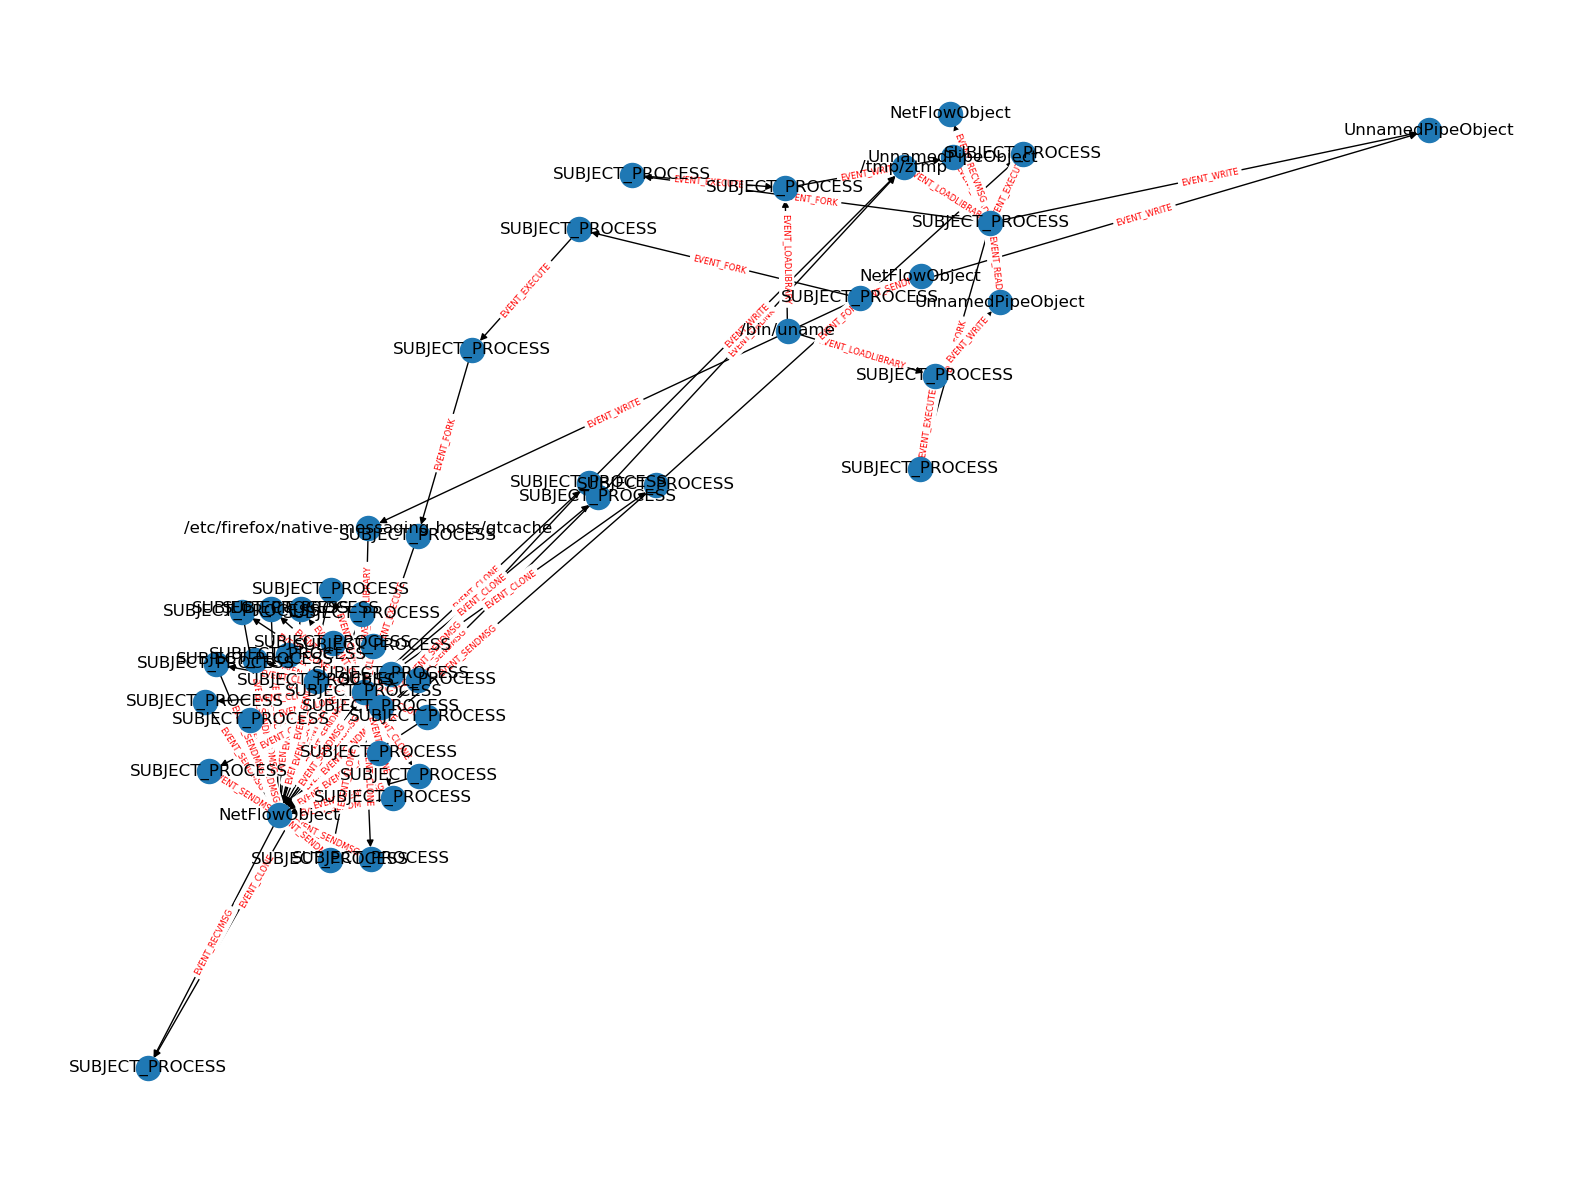

In [42]:
nodeLabels = {}
for node in TestGraph.nodes:
    if TestGraph.nodes[node]['path'] and TestGraph.nodes[node]['path'] != '<unknown>':
        nodeLabels[node] = TestGraph.nodes[node]['path']
    else:
        nodeLabels[node] = TestGraph.nodes[node]['type']
EdgeLabels = {}
for edge in TestGraph.edges(data=True):
    EdgeLabels[(edge[0],edge[1])] = edge[2]['type']
nodes_to_draw = TestGraph.nodes
edges_to_draw = TestGraph.edges
# pos = nx.spring_layout(TestGraph,k = 100)
pos = nx.spring_layout(TestGraph)
plt.figure(figsize=(20,15))
nx.draw_networkx_nodes(TestGraph, pos,
                       nodelist=nodes_to_draw,)

# 画边
nx.draw_networkx_edges(TestGraph, pos,
                       edgelist=edges_to_draw,)

# 画标签
nx.draw_networkx_edge_labels(TestGraph, pos, edge_labels=EdgeLabels, font_color='red', font_size=6)
nx.draw_networkx_labels(TestGraph, pos, font_size=12, labels=nodeLabels,font_color='black') 
plt.axis("off")
plt.show()


In [43]:
import networkx as nx


# with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Cadets\\Reduced\\SubGraph_sk_db_bid_lll.data",'wb') as f:
#     pickle.dump(SubGraph,f)
a = [n for n in SubGraph.nodes if n not in TestGraph.nodes]
SubGraph.remove_nodes_from(a)

In [44]:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Trace\\Reduced\\C315_FinalResult_Fail.data",'wb') as f:
    pickle.dump(SubGraph,f)